In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

In [2]:
song_features = pd.read_csv("../data/song_features_processed.csv")

titles = song_features["Title"]
X = song_features.drop(columns=["Title"])

**Feature Scaling**  
All numeric features were standardized during the preprocessing step using StandardScaler. The modeling notebook uses the pre-scaled feature set directly to avoid double scaling.

In [3]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

**Model Choice and Evaluation**  
Since we are doing unsupervised learning, silhouette score will be used as the primary evaluation metric. This measures both cluster cohesion and separation without requiring labeled data.  

Three clustering algorithms will be explored: K-Means, Agglomerative Clustering, and Gaussian Mixture Models.

In [4]:
k_values = range(2, 9)
kmeans_train_scores = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_train)
    kmeans_train_scores[k] = silhouette_score(X_train, labels)

kmeans_train_scores

{2: np.float64(0.18798536331869603),
 3: np.float64(0.1342779064705714),
 4: np.float64(0.1342939360657563),
 5: np.float64(0.11153899136153195),
 6: np.float64(0.1092757990244256),
 7: np.float64(0.12692743988362254),
 8: np.float64(0.1213646025199016)}

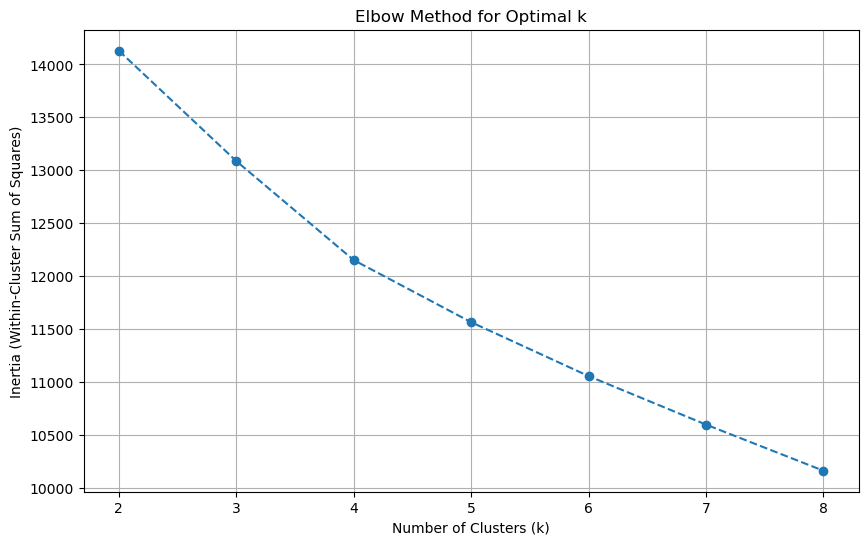

In [5]:
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [6]:
best_k = max(kmeans_train_scores, key=kmeans_train_scores.get)
best_k

2

In [7]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

kmeans_train_labels = kmeans.fit_predict(X_train)
kmeans_test_labels = kmeans.predict(X_test)

kmeans_train_sil = silhouette_score(X_train, kmeans_train_labels)
kmeans_test_sil = silhouette_score(X_test, kmeans_test_labels)

kmeans_train_sil, kmeans_test_sil

(np.float64(0.18798536331869603), np.float64(0.2018587064173722))

In [8]:
agg = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

agg_train_labels = agg.fit_predict(X_train)
agg_test_labels = agg.fit_predict(X_test)

agg_train_sil = silhouette_score(X_train, agg_train_labels)
agg_test_sil = silhouette_score(X_test, agg_test_labels)

agg_train_sil, agg_test_sil

(np.float64(0.15027831867392447), np.float64(0.21957829976619636))

In [9]:
gmm_train_scores = {}

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    labels = gmm.fit_predict(X_train)
    gmm_train_scores[k] = silhouette_score(X_train, labels)

gmm_train_scores

{2: np.float64(0.16995866687861633),
 3: np.float64(0.10638187951186381),
 4: np.float64(0.10248759601035236),
 5: np.float64(0.067783858704592),
 6: np.float64(0.07020018202293013),
 7: np.float64(0.0599038537218893),
 8: np.float64(0.018765816608718757)}

In [10]:
best_gmm_k = max(gmm_train_scores, key=gmm_train_scores.get)
best_gmm_k

2

In [11]:
gmm = GaussianMixture(
    n_components=best_gmm_k,
    random_state=42
)

gmm_train_labels = gmm.fit_predict(X_train)
gmm_test_labels = gmm.predict(X_test)

gmm_train_sil = silhouette_score(X_train, gmm_train_labels)
gmm_test_sil = silhouette_score(X_test, gmm_test_labels)

gmm_train_sil, gmm_test_sil

(np.float64(0.16995866687861633), np.float64(0.10996873945162483))

In [12]:
model_comparison = pd.DataFrame({
    "Model": ["KMeans", "Agglomerative", "GMM"],
    "Train Silhouette": [
        kmeans_train_sil,
        agg_train_sil,
        gmm_train_sil
    ],
    "Test Silhouette": [
        kmeans_test_sil,
        agg_test_sil,
        gmm_test_sil
    ]
})

model_comparison.sort_values("Test Silhouette", ascending=False)

,Model,Train Silhouette,Test Silhouette
1,Agglomerative,0.150278,0.219578
0,KMeans,0.187985,0.201859
2,GMM,0.169959,0.109969


**Results**  
The silhouette scores across all models are modest, indicating overlapping clusters. This is expected given the high dimensionality of the feature space and the stylistic continuity of jazz standards. Music style does not exhibit sharply separable boundaries, and many songs share characteristics across harmonic and rhythmic dimensions.

Despite this, both KMeans and Agglomerative Clustering show consistent performance on unseen data, suggesting stable and meaningful structure. KMeans was selected as the final model due to its slightly higher and more consistent silhouette scores, interpretability, and lower computational complexity.

**We will now explore the clusters**

In [13]:
final_clusters = song_features.copy()

final_clusters.loc[X_train.index, "cluster"] = kmeans_train_labels
final_clusters.loc[X_test.index, "cluster"] = kmeans_test_labels

In [14]:
final_clusters["cluster"].isna().sum()

np.int64(0)

In [15]:
final_clusters.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,...,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin,cluster
0,26-2,1.244329,-0.913729,2.102109,-0.897150,2.032590,-0.643598,0.410345,-0.914208,-0.716949,...,False,False,True,False,False,False,False,False,False,0.0
1,500 Miles High,-1.321162,0.999274,-1.394632,-0.897150,0.394162,2.166027,-1.502324,1.305757,0.103649,...,False,True,False,False,False,False,False,False,False,1.0
2,502 Blues,-1.321162,1.381874,-1.465534,-0.897150,0.771260,0.202674,-0.445802,2.045745,0.650714,...,False,False,False,False,False,False,False,False,False,1.0
3,52nd Street Theme,-0.180944,-0.913729,0.651848,0.881320,-1.114233,0.512677,-0.153868,-0.914208,-0.716949,...,False,False,False,False,False,False,False,False,False,0.0
4,9.20 Special,-0.252207,-0.531128,0.042738,1.690444,-1.114233,-1.760678,0.689245,-0.914208,0.421538,...,False,False,False,False,False,False,False,False,False,1.0


In [16]:
final_clusters.dtypes

Title                      object
n_chords                  float64
n_measures                float64
chords_per_measure        float64
pct_triad                 float64
pct_maj7                  float64
pct_m7                    float64
pct_dominant              float64
pct_diminished            float64
pct_extensions_9plus      float64
mean_root_motion          float64
pct_desc_fifth            float64
root_pc_entropy           float64
Year                      float64
Rhythm_Ballad                bool
Rhythm_Bossa Nova            bool
Rhythm_Calypso               bool
Rhythm_Even 16ths            bool
Rhythm_Even 8ths             bool
Rhythm_Funk                  bool
Rhythm_Latin                 bool
Rhythm_Latin-Swing           bool
Rhythm_Medium Slow           bool
Rhythm_Medium Swing          bool
Rhythm_Medium Up Swing       bool
Rhythm_Rock Pop              bool
Rhythm_Samba                 bool
Rhythm_Slow Rock             bool
Rhythm_Slow Swing            bool
Rhythm_Up Temp

In [17]:
numeric_scaled_cols = [
    "n_chords", "n_measures", "chords_per_measure",
    "pct_triad", "pct_maj7", "pct_m7", "pct_dominant", "pct_diminished",
    "pct_extensions_9plus", "mean_root_motion", "pct_desc_fifth", "root_pc_entropy", "Year"
]

categorical_cols = final_clusters.select_dtypes(include='bool').columns.tolist()

In [18]:
import joblib

scaler = joblib.load("scaler.pkl")

In [19]:
final_clusters_unscaled = final_clusters.copy()

# Inverse transform numeric columns
final_clusters_unscaled[numeric_scaled_cols] = scaler.inverse_transform(
    final_clusters[numeric_scaled_cols]
)

final_clusters_unscaled["cluster"] = final_clusters_unscaled["cluster"].astype(int)

final_clusters_unscaled.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,...,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin,cluster
0,26-2,58.0,8.0,7.250000,0.000000,0.379310,0.155172,0.465517,0.000000,0.000000,...,False,False,True,False,False,False,False,False,False,0
1,500 Miles High,22.0,18.0,1.222222,0.000000,0.181818,0.545455,0.136364,0.136364,0.136364,...,False,True,False,False,False,False,False,False,False,1
2,502 Blues,22.0,20.0,1.100000,0.000000,0.227273,0.272727,0.318182,0.181818,0.227273,...,False,False,False,False,False,False,False,False,False,1
3,52nd Street Theme,38.0,8.0,4.750000,0.315789,0.000000,0.315789,0.368421,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,0
4,9.20 Special,37.0,10.0,3.700000,0.459459,0.000000,0.000000,0.513514,0.000000,0.189189,...,False,False,False,False,False,False,False,False,False,1


In [20]:
cluster_numeric_means = (
    final_clusters_unscaled
    .groupby("cluster")[numeric_scaled_cols]
    .mean()
)

cluster_categorical_props = (
    final_clusters_unscaled
    .groupby("cluster")[categorical_cols]
    .mean()
)

cluster_summary = pd.concat(
    [cluster_numeric_means, cluster_categorical_props],
    axis=1
)

cluster_summary.head()

,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,mean_root_motion,...,Key_Eb,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin
cluster,,,,,,,,,,,,,,,,,,,,,
0,44.104526,11.369612,4.234468,0.111757,0.125272,0.271675,0.418665,0.060952,0.076685,3.685070,...,0.189655,0.004310,0.004310,0.209052,0.001078,0.018319,0.094828,0.000000,0.000000,0.014009
1,33.251101,15.651982,2.383254,0.256481,0.152775,0.189178,0.346324,0.046353,0.205919,2.488628,...,0.070485,0.015419,0.017621,0.132159,0.000000,0.041850,0.066079,0.004405,0.002203,0.030837


In [21]:
cluster_summary[
    [
        "n_chords",
        "pct_maj7",
        "pct_m7",
        "pct_dominant",
        "pct_diminished",
        "pct_extensions_9plus",
        "mean_root_motion",
        "pct_desc_fifth",
        "Year"
    ]
]

,n_chords,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,mean_root_motion,pct_desc_fifth,Year
cluster,,,,,,,,,
0,44.104526,0.125272,0.271675,0.418665,0.060952,0.076685,3.685070,0.583906,1943.350535
1,33.251101,0.152775,0.189178,0.346324,0.046353,0.205919,2.488628,0.328766,1953.941182


In [22]:
cluster_summary[
    categorical_cols
]

,Rhythm_Ballad,Rhythm_Bossa Nova,Rhythm_Calypso,Rhythm_Even 16ths,Rhythm_Even 8ths,Rhythm_Funk,Rhythm_Latin,Rhythm_Latin-Swing,Rhythm_Medium Slow,Rhythm_Medium Swing,...,Key_Eb,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.251078,0.034483,0.001078,0.000000,0.007543,0.004310,0.015086,0.001078,0.002155,0.41056,...,0.189655,0.004310,0.004310,0.209052,0.001078,0.018319,0.094828,0.000000,0.000000,0.014009
1,0.088106,0.083700,0.000000,0.002203,0.063877,0.017621,0.046256,0.000000,0.000000,0.27533,...,0.070485,0.015419,0.017621,0.132159,0.000000,0.041850,0.066079,0.004405,0.002203,0.030837


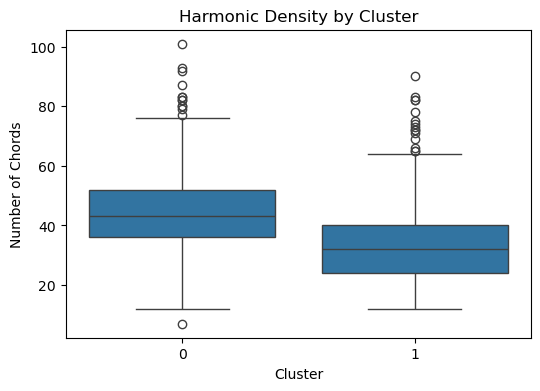

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="n_chords"
)
plt.title("Harmonic Density by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Chords")
plt.show()

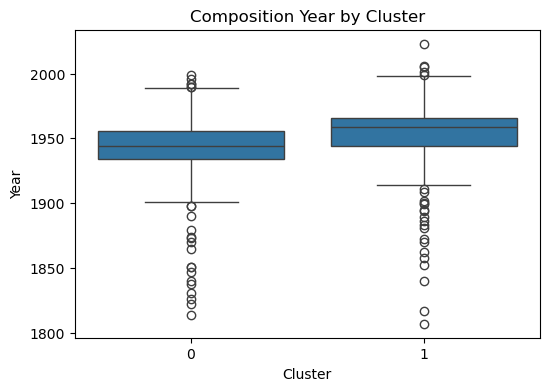

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="Year"
)
plt.title("Composition Year by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Year")
plt.show()

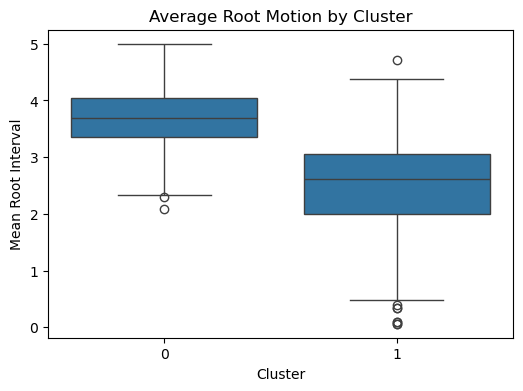

In [25]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="mean_root_motion"
)
plt.title("Average Root Motion by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Root Interval")
plt.show()

In [26]:
rhythm_cols = [col for col in final_clusters.columns if col.startswith("Rhythm_")]

rhythm_summary = (
    final_clusters
    .groupby("cluster")[rhythm_cols]
    .mean()
    .T
)

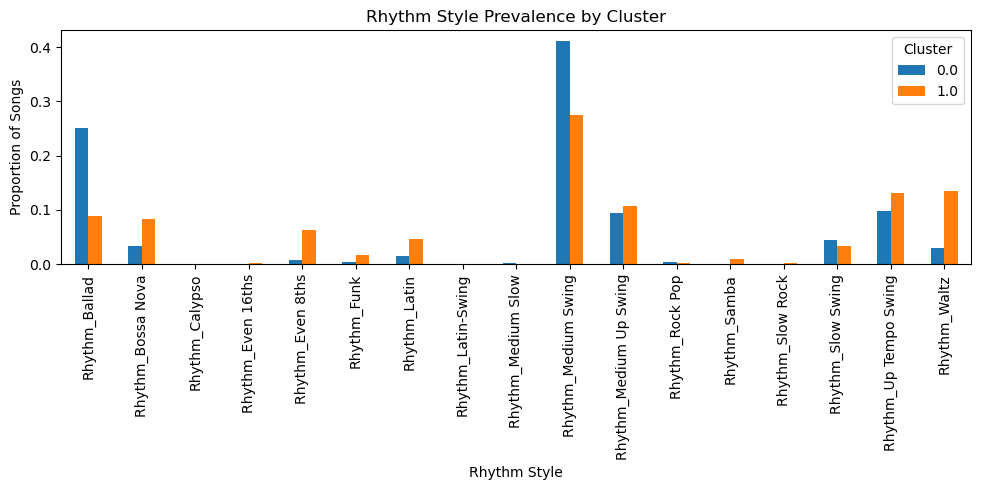

In [27]:
rhythm_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Rhythm Style Prevalence by Cluster")
plt.ylabel("Proportion of Songs")
plt.xlabel("Rhythm Style")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [28]:
key_cols = [col for col in final_clusters.columns if col.startswith("Key_")]

key_summary = (
    final_clusters
    .groupby("cluster")[key_cols]
    .mean()
    .T
)

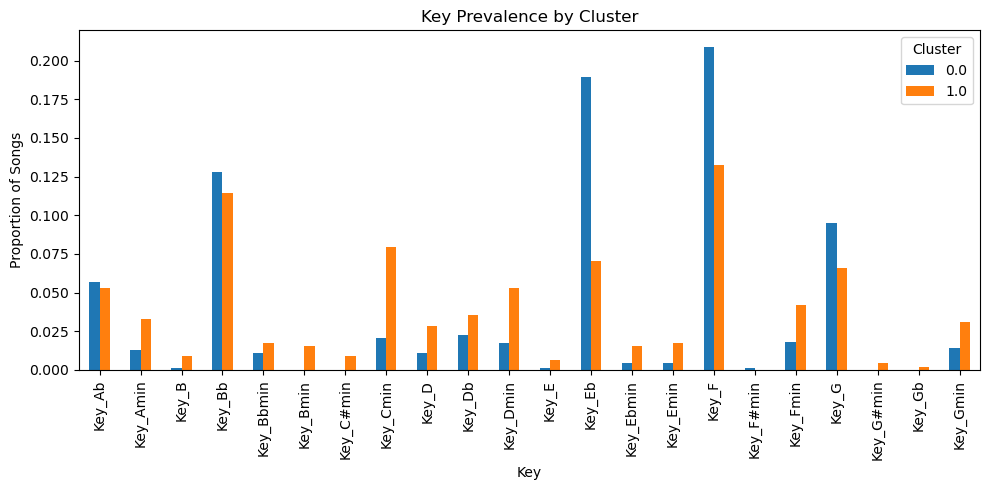

In [29]:
key_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Key Prevalence by Cluster")
plt.ylabel("Proportion of Songs")
plt.xlabel("Key")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df["cluster"] = final_clusters["cluster"]

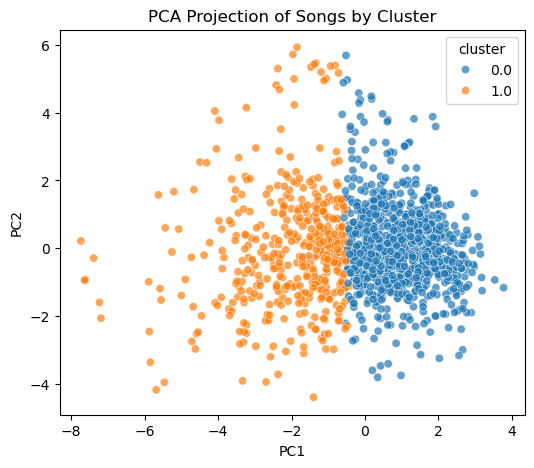

In [31]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    alpha=0.7
)
plt.title("PCA Projection of Songs by Cluster")
plt.show()

In [32]:
df = final_clusters_unscaled.copy()

# Collapse Rhythm columns
rhythm_cols = [col for col in df.columns if col.startswith("Rhythm_")]
df["Rhythm"] = df[rhythm_cols].idxmax(axis=1).str.replace("Rhythm_", "")

# Collapse TimeSignature columns
ts_cols = [col for col in df.columns if col.startswith("TimeSignature_")]
df["TimeSignature"] = df[ts_cols].idxmax(axis=1).str.replace("TimeSignature_", "")

# Drop the original dummy columns
df = df.drop(columns=rhythm_cols + ts_cols)

final_clusters_unscaled_collapsed = df

final_clusters_unscaled_collapsed.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,...,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin,cluster,Rhythm,TimeSignature
0,26-2,58.0,8.0,7.250000,0.000000,0.379310,0.155172,0.465517,0.000000,0.000000,...,True,False,False,False,False,False,False,0,Medium Up Swing,4/4
1,500 Miles High,22.0,18.0,1.222222,0.000000,0.181818,0.545455,0.136364,0.136364,0.136364,...,False,False,False,False,False,False,False,1,Bossa Nova,4/4
2,502 Blues,22.0,20.0,1.100000,0.000000,0.227273,0.272727,0.318182,0.181818,0.227273,...,False,False,False,False,False,False,False,1,Waltz,3/4
3,52nd Street Theme,38.0,8.0,4.750000,0.315789,0.000000,0.315789,0.368421,0.000000,0.000000,...,False,False,False,False,False,False,False,0,Up Tempo Swing,4/4
4,9.20 Special,37.0,10.0,3.700000,0.459459,0.000000,0.000000,0.513514,0.000000,0.189189,...,False,False,False,False,False,False,False,1,Medium Swing,4/4


In [33]:
# Peek at first 5 songs per cluster
final_clusters_unscaled_collapsed.sort_values("cluster").groupby("cluster").head(5)[["cluster", "Title", "Year", "Rhythm", "TimeSignature"]]

,cluster,Title,Year,Rhythm,TimeSignature
0,0,26-2,1941.0,Medium Up Swing,4/4
647,0,Is You Is Or Is You Ain't (Ma' Baby),1943.0,Medium Swing,4/4
649,0,Island Birdie,1963.0,Calypso,4/4
650,0,Isn't It A Pity,1970.0,Ballad,4/4
651,0,Isn't It Romantic?,1932.0,Medium Swing,4/4
1043,1,Sail Away,1989.0,Bossa Nova,4/4
1056,1,Sea Journey,1971.0,Latin,4/4
1199,1,Theme From Family Guy,1999.0,Medium Swing,4/4
1031,1,Robbin's Nest,1968.0,Medium Swing,4/4
1232,1,Time Remembered,1962.0,Ballad,4/4


## Summary of Differences Between the Two Clusters

**Cluster 0 – Denser / Classic / More Traditional Jazz-Heavy Profile**
- Average year: ~1945 (earlier, golden-age jazz period)
- Harmonic density: clearly higher  
  - median ~1 added chord  
  - many songs with 2–4 extensions / alterations
- Chord quality profile:
  - higher proportion of minor 7ths, and dominant 7ths (~42% )
  - fewer major 7ths, more diminished chords
- Root motion:
  - larger average steps (~3.7 semitones)
  - much more downward-fifth movement (~58%)
- Rhythm — very strongly dominated by swing:
  - Medium Slow and especially Medium Swing (~42% + ~40% combined)
  - Much lower prevalence of ballads, bossa nova, even 8ths, funk, Latin, rock, waltz
- Time signature: overwhelmingly 4/4 (~95%)

**Cluster 1 – Simpler / More Modern / Varied Harmonic & Rhythmic Profile**
- Average year: ~1959 
- Harmonic density: lower  
  - many songs with very few or no extensions/alterations
- Chord quality profile:
  - more major 7ths (~16%)
  - fewer minor 7ths and dominant 7ths
- Root motion:
  - smaller average steps (~2.5 semitones)
  - less downward-fifth movement (~34%)
- Rhythm — much more even distribution across styles:
  - Strong presence of Ballad, Bossa Nova, Even 8ths
  - Notable Slow Tempo Swing, Up Tempo Swing, Waltz
  - More Funk, Latin, Rock-related rhythms
- Time signature: slightly more 3/4, 5/4, 6/4 (still very minor)

## Conclusion

Cluster 0 captures **earlier, denser, swing-centric traditional jazz** (1940s bebop/hard-bop era core), while Cluster 1 represents **later, simpler, more diverse rhythm & popular-jazz styles** (post-1950s feel).